In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [58]:
# LOAD DATASET

df = pd.read_csv("populationgroup-wise-deposits.csv")


In [59]:
# DATA CLEANING

df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))

In [75]:
# CREATE FOLDER FOR SAVING GRAPH

os.makedirs("regression_graphs", exist_ok=True)

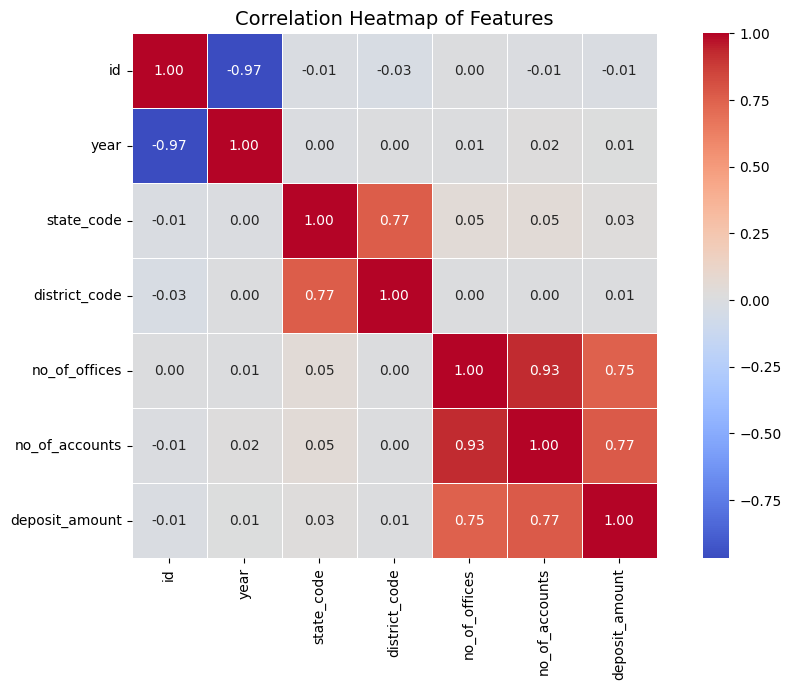

In [60]:
# HEATMAP (EDA)


corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Features", fontsize=14)
plt.tight_layout()
plt.savefig("regression_graphs/correlation_heatmap.png")
plt.show()

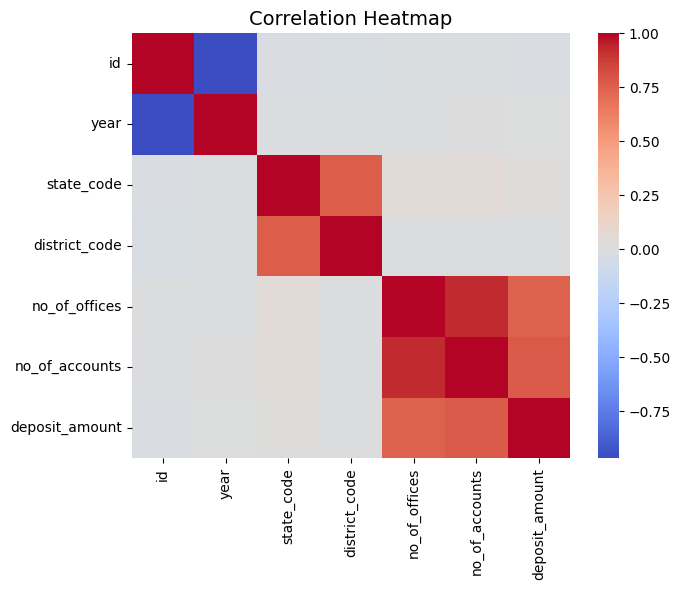

In [61]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

plt.figure(figsize=(7,6))
ax = sns.heatmap(
    corr,
    cmap="coolwarm",   
    annot=False,       
    linewidths=0,      
    cbar=True
)

plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

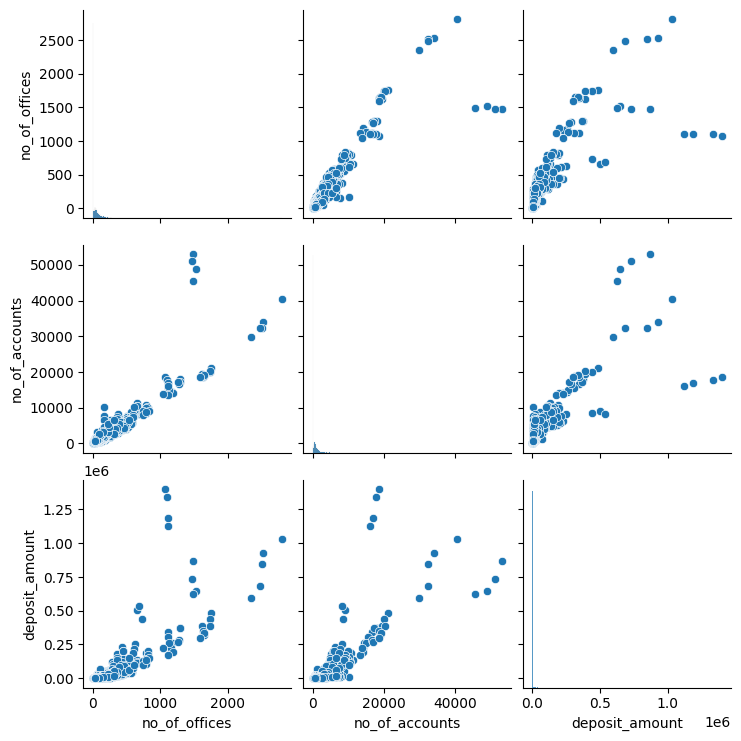

In [62]:
# Pairplot (All numeric columns)
sns.pairplot(df[['no_of_offices', 'no_of_accounts', 'deposit_amount']])
plt.savefig("regression_graphs/pairplot.png")
plt.show()

In [63]:
# Feature selection for regression
X = df[['no_of_offices', 'no_of_accounts']]
y = df['deposit_amount']

In [64]:

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
# FUNCTION TO RUN ANY MODEL

comparison_results = []

def run_model(name, model):

    
    print(f"  MODEL : {name}")

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    preds = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    print(f"R² Score          : {r2:.4f}")
    print(f"MAE               : {mae:.4f}")
    print(f"MSE               : {mse:.4f}")
    print(f"RMSE              : {rmse:.4f}")

    # Save results for comparison
    comparison_results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

    # Plot Actual vs Predicted
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, preds)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{name} - Actual vs Predicted")
    plt.tight_layout()
    plt.savefig(f"regression_graphs/{name.replace(' ', '_')}.png")
    plt.show()

  MODEL : Linear Regression
R² Score          : 0.6777
MAE               : 8175.8557
MSE               : 466206036.7754
RMSE              : 21591.8049


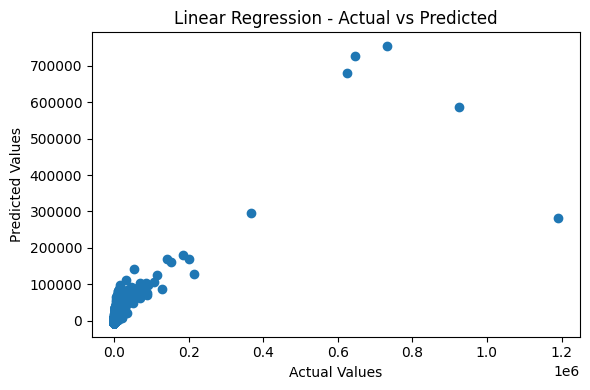

In [67]:
#Linear Regression

run_model("Linear Regression", LinearRegression())

  MODEL : Decision Tree
R² Score          : 0.9507
MAE               : 1714.1121
MSE               : 71359066.7609
RMSE              : 8447.4296


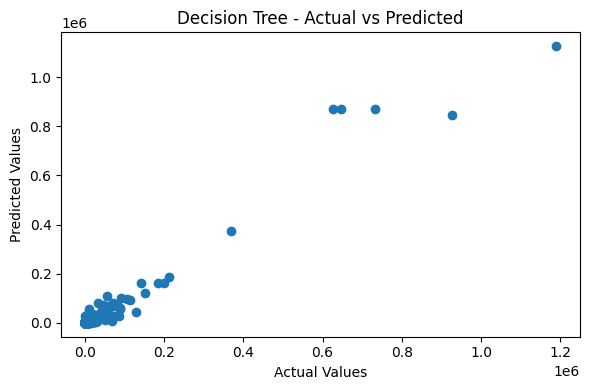

In [68]:
# Decision Tree Regressor

run_model("Decision Tree", DecisionTreeRegressor(random_state=42))

  MODEL : Random Forest
R² Score          : 0.9308
MAE               : 1581.1298
MSE               : 100076909.7984
RMSE              : 10003.8448


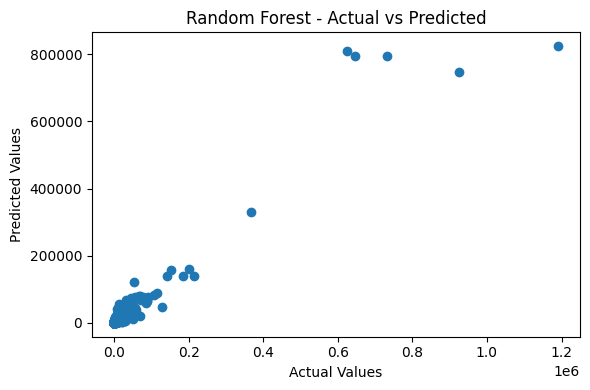

In [69]:
# Random Forest Regressor

run_model("Random Forest", RandomForestRegressor(random_state=42))

  MODEL : KNN Regressor
R² Score          : 0.8733
MAE               : 1916.2846
MSE               : 183310996.3397
RMSE              : 13539.2391


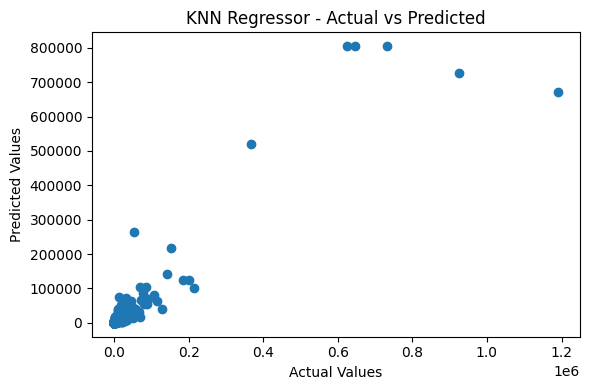

In [70]:
# KNN Regressor

run_model("KNN Regressor", KNeighborsRegressor())

  MODEL : SVR
R² Score          : -0.0049
MAE               : 3882.1522
MSE               : 1453679864.2206
RMSE              : 38127.1539


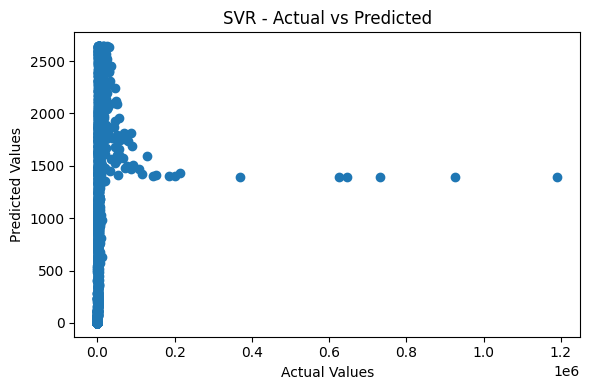

In [71]:
# Support Vector Regressor

run_model("SVR", SVR())

In [72]:
# FINAL COMPARISON OF MODELS

results_df = pd.DataFrame(comparison_results)
print("\n\n             FINAL MODEL COMPARISON               \n")
print(results_df)



             FINAL MODEL COMPARISON               

               Model        R2          MAE           MSE          RMSE
0  Linear Regression  0.677722  8175.855713  4.662060e+08  21591.804852
1      Decision Tree  0.950671  1714.112061  7.135907e+07   8447.429595
2      Random Forest  0.930819  1581.129783  1.000769e+08  10003.844751
3      KNN Regressor  0.873281  1916.284615  1.833110e+08  13539.239134
4                SVR -0.004898  3882.152220  1.453680e+09  38127.153896


In [73]:
# Save comparison table

results_df.to_csv("regression_graphs/final_model_comparison.csv", index=False)


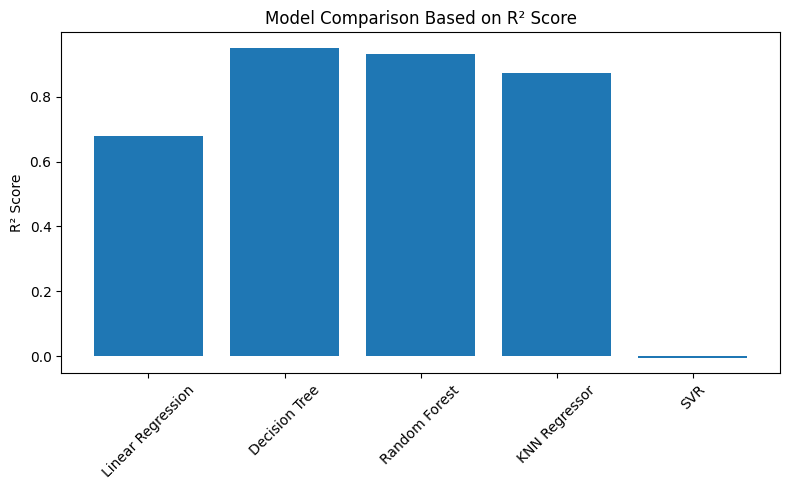

In [74]:
# SIMPLE VISUAL COMPARISON (R² SCORE)

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2"])
plt.ylabel("R² Score")
plt.title("Model Comparison Based on R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("regression_graphs/final_r2_comparison.png")
plt.show()